# Complex coil geometry: the CoilBuilder fluent API

Canonical example of `radia.coil_builder.CoilBuilder` -- an 8-segment beam-steering magnet coil built as a continuous path (`add_straight` / `add_arc` with tilt), the way beam-optics coils are specified. `to_radia()` turns the path into a Biot-Savart source (**no coil mesh needed**); the field is then evaluated analytically with `rad.Fld`.

*Notebook-coupled helpers now live beside this notebook in `docs/complex_coil_geometry/` and are cited by `docs/api/CoilBuilder.md`. The full ParaView VTK field-map export lives in `field_map.py`; here we render a fast matplotlib slice instead.*

## See a bent beam-steering coil and its magnetic field

Rotate the actual eight-segment CoilBuilder solid, then inspect the field beside
it. This is Radia's geometry-to-source-field capability; its MCP coil and
NGSolve tools own the operating workflow. The new field is the **finite-wire
centreline approximation** of that geometry at 1265 A, not a rerun of the
historical thick-conductor calculation below. The mesh is a sampling slab
200 mm from the coil plane along x, not an air-boundary FEM solve.
The scalar scene shows strength, and the vector scene shows direction.


In [1]:
from pathlib import Path
import hashlib, json, math, platform, socket, sys
from datetime import datetime, timezone
from importlib.metadata import version
import ngsolve as ng
from ngsolve.webgui import Draw
ng.SetNumThreads(2)
import numpy as np
from coil_model import create_beam_steering_builder
from radia.biot_savart import h_segments_cf, h_segments_batch, MU0
from netgen.occ import Box, Pnt, OCCGeometry
builder=create_beam_steering_builder()
solid=builder.to_occ()
segments,current=builder.to_wire_segments(n_arc=60)
points=np.asarray(segments).reshape(-1,3)
lo,hi=points.min(axis=0),points.max(axis=0)
xview=float(hi[0]+0.2)
with ng.TaskManager():
    mesh=ng.Mesh(OCCGeometry(Box(Pnt(xview,lo[1],lo[2]), Pnt(xview+0.05,hi[1],hi[2]))).GenerateMesh(maxh=0.20))
    B=MU0*h_segments_cf(segments,current=current)
    probes=np.array([[xview+0.025,float(lo[1]+a*(hi[1]-lo[1])),float(lo[2]+b*(hi[2]-lo[2]))] for a in (0.1,0.5,0.9) for b in (0.1,0.5,0.9)])
    actual=np.array([B(mesh(*p)) for p in probes])
    reference=MU0*h_segments_batch(segments,probes,current=current)
    difference=float(np.linalg.norm(actual-reference)/np.linalg.norm(reference))
    assert np.isfinite(actual).all() and difference < 0.05, difference
metrics=dict(current_A=current,segments=len(segments),sampling_x_m=xview,
             relative_cf_vs_finite_segment_gap=difference,field_route='centreline Biot-Savart, not thick conductor',
             geometry_source_sha256=hashlib.sha256(Path('coil_model.py').read_bytes()).hexdigest(),
             geometry_source=Path('coil_model.py').read_text(encoding='utf-8'))
print(json.dumps({k:v for k,v in metrics.items() if k!='geometry_source'},indent=2))


{
  "current_A": 1265.0,
  "segments": 244,
  "sampling_x_m": 0.41800000000000004,
  "relative_cf_vs_finite_segment_gap": 5.769593556666209e-16,
  "field_route": "centreline Biot-Savart, not thick conductor",
  "geometry_source_sha256": "a929eab2772347da3d93d55ff088de9b09d1ffcc8bb722a3a72c8e1da03d85b1"
}


### Bent coil: real CoilBuilder CAD

In [2]:
from netgen.webgui import Draw as DrawGeometry
scene=DrawGeometry(solid,width='100%',height='480px')
scene.GenerateHTML(filename='scene_0.html')


'\n<!DOCTYPE html>\n<html>\n    <head>\n        <title>NGSolve WebGUI</title>\n        <meta name=\'viewport\' content=\'width=device-width, user-scalable=no\'/>\n        <style>\n            body{\n                margin:0;\n                overflow:hidden;\n            }\n            canvas{\n                cursor:grab;\n                cursor:-webkit-grab;\n                cursor:-moz-grab;\n            }\n            canvas:active{\n                cursor:grabbing;\n                cursor:-webkit-grabbing;\n                cursor:-moz-grabbing;\n            }\n        </style>\n    </head>\n    <body>\n          <script src="https://cdn.jsdelivr.net/npm/webgui@0.2.39/dist/webgui.js"></script>\n          </script>\n          <script>\n            var render_data = {"ngsolve_version": "Netgen x.x", "mesh_dim": 3, "mesh_center": [0.21800000000000003, 1.5902501537823355e-11, 0.49999999999495653], "mesh_radius": 0.9053489128516505, "order2d": 1, "order3d": 0, "draw_vol": false, "draw_s

### Field sampling slab mesh

In [3]:
scene=Draw(mesh,name='Field_sampling_slab',draw_vol=False,draw_surf=True,width='100%',height='480px')
scene.GenerateHTML(filename='scene_1.html')


'\n<!DOCTYPE html>\n<html>\n    <head>\n        <title>NGSolve WebGUI</title>\n        <meta name=\'viewport\' content=\'width=device-width, user-scalable=no\'/>\n        <style>\n            body{\n                margin:0;\n                overflow:hidden;\n            }\n            canvas{\n                cursor:grab;\n                cursor:-webkit-grab;\n                cursor:-moz-grab;\n            }\n            canvas:active{\n                cursor:grabbing;\n                cursor:-webkit-grabbing;\n                cursor:-moz-grabbing;\n            }\n        </style>\n    </head>\n    <body>\n          <script src="https://cdn.jsdelivr.net/npm/webgui@0.2.39/dist/webgui.js"></script>\n          </script>\n          <script>\n            var render_data = {"gui_settings": {}, "ngsolve_version": "6.2.2606", "mesh_dim": 3, "order2d": 1, "order3d": 1, "draw_vol": null, "draw_surf": null, "objects": [], "deformation": false, "mesh_regions_2d": 6, "mesh_regions_3d": 1, "names":

### Magnetic flux density magnitude (tesla)

In [4]:
with ng.TaskManager():
    scene=Draw(ng.Norm(B),mesh,name='Centreline_B_magnitude_T',draw_vol=False,draw_surf=True,autoscale=True,clipping=None,width='100%',height='480px')
scene.GenerateHTML(filename='scene_2.html')


'\n<!DOCTYPE html>\n<html>\n    <head>\n        <title>NGSolve WebGUI</title>\n        <meta name=\'viewport\' content=\'width=device-width, user-scalable=no\'/>\n        <style>\n            body{\n                margin:0;\n                overflow:hidden;\n            }\n            canvas{\n                cursor:grab;\n                cursor:-webkit-grab;\n                cursor:-moz-grab;\n            }\n            canvas:active{\n                cursor:grabbing;\n                cursor:-webkit-grabbing;\n                cursor:-moz-grabbing;\n            }\n        </style>\n    </head>\n    <body>\n          <script src="https://cdn.jsdelivr.net/npm/webgui@0.2.39/dist/webgui.js"></script>\n          </script>\n          <script>\n            var render_data = {"gui_settings": {}, "ngsolve_version": "6.2.2606", "mesh_dim": 3, "order2d": 2, "order3d": 2, "draw_vol": false, "draw_surf": true, "objects": [], "deformation": false, "funcdim": 1, "show_wireframe": true, "show_mesh": 

### Magnetic flux density direction

In [5]:
with ng.TaskManager():
    scene=Draw(B,mesh,name='Centreline_B_vectors_T',draw_vol=False,draw_surf=True,vectors={'grid_size':12},autoscale=True,clipping=None,width='100%',height='480px')
scene.GenerateHTML(filename='scene_3.html')


'\n<!DOCTYPE html>\n<html>\n    <head>\n        <title>NGSolve WebGUI</title>\n        <meta name=\'viewport\' content=\'width=device-width, user-scalable=no\'/>\n        <style>\n            body{\n                margin:0;\n                overflow:hidden;\n            }\n            canvas{\n                cursor:grab;\n                cursor:-webkit-grab;\n                cursor:-moz-grab;\n            }\n            canvas:active{\n                cursor:grabbing;\n                cursor:-webkit-grabbing;\n                cursor:-moz-grabbing;\n            }\n        </style>\n    </head>\n    <body>\n          <script src="https://cdn.jsdelivr.net/npm/webgui@0.2.39/dist/webgui.js"></script>\n          </script>\n          <script>\n            var render_data = {"gui_settings": {}, "ngsolve_version": "6.2.2606", "mesh_dim": 3, "order2d": 2, "order3d": 2, "draw_vol": false, "draw_surf": true, "objects": [], "deformation": false, "funcdim": 3, "show_wireframe": true, "show_mesh": 

In [6]:
evidence=dict(schema='radia.docs.webgui_supplement.v1',
    generated_at_utc=datetime.now(timezone.utc).isoformat(),host=socket.gethostname(),
    python_executable=sys.executable,python_version=platform.python_version(),
    versions={p:version(p) for p in ['ngsolve','netgen-mesher','anywidget','cubit-mesh-export']},
    metrics=metrics,threads=2)
Path('evidence.json').write_text(json.dumps(evidence,indent=2),encoding='utf-8')


3875

## Coil definition (CoilBuilder fluent path)

In [1]:
import sys, os
sys.argv = ["notebook"]

#!/usr/bin/env python
# -*- coding: utf-8 -*-
"""
Complex coil model definition

This module defines the 8-segment beam steering coil geometry.
The model can be imported by other scripts for visualization or field calculation.

Units: All geometry in meters (Radia always uses meters), current in Amperes.
"""

import sys
from pathlib import Path

# Add paths
project_root = Path(os.path.join(os.getcwd(), 'notebook.py')).resolve().parent.parent.parent

import numpy as np
import radia as rad
from radia.coil_builder import CoilBuilder

# Set unit system to meters

# Unit conversion factor: original design values are in mm
mm = 1e-3  # 1 mm in meters


def create_beam_steering_coil():
	"""
	Create the 8-segment beam steering magnet coil.

	Returns:
		tuple: (coil_object, coil_parameters)
			- coil_object: Radia object ID
			- coil_parameters: Dictionary with coil specifications
	"""
	# Coil parameters
	I = 1265.0       # Current (A)
	W = 122 * mm     # Width: 122 mm -> 0.122 m
	H = 122 * mm     # Height: 122 mm -> 0.122 m

	# Initial orientation and position
	V = np.array([[1, 0, 0], [0, 1, 0], [0, 0, 1]]).T
	L_start = 16.43186645 * 2 * mm
	x0 = np.array([(48 + 170) * mm, -L_start / 2, -20 * mm - W / 2])

	# Build coil using modern fluent interface
	coil_segments = (CoilBuilder(current=I)
		.set_start(x0, V)
		.set_cross_section(width=W, height=H)
		.add_straight(length=16.43186645 * 2 * mm, tilt=0)
		.add_arc(radius=121 * mm, arc_angle=64.59228189, tilt=90)
		.add_straight(length=1018.51313197 * mm, tilt=90)
		.add_arc(radius=121 * mm, arc_angle=115.40771811, tilt=-90)
		.add_straight(length=453.43186645 * 2 * mm, tilt=90)
		.add_arc(radius=121 * mm, arc_angle=115.40771811, tilt=-90)
		.add_straight(length=1018.51313197 * mm, tilt=90)
		.add_arc(radius=121 * mm, arc_angle=64.59228189, tilt=-90)
		.to_radia()
	)

	# Combine all coils
	coils_container = rad.ObjCnt(coil_segments)

	# Note: TrfZerPara was removed from API (2026-01-31).
	# Symmetry hint is optional; field calculation is still correct without it.

	# Store parameters for reference
	parameters = {
		'current': I,
		'cross_section': {'width': W, 'height': H},
		'num_segments': len(coil_segments),
		'description': '8-segment beam steering magnet coil'
	}

	return coils_container, parameters




## Field of the assembled coil

\\192.168.11.100\work\00_CAE\Radia\01_GitHub\src\radia\coil_builder.py:79: UserWarning: Gimbal lock detected. Setting third angle to zero since it is not possible to uniquely determine all angles.
  self.euler_angles = rot.as_euler('ZXZ', degrees=True) * (-1)


8-segment beam-steering coil:
  current: 1265.0
  cross_section: {'width': 0.122, 'height': 0.122}
  num_segments: 8
  description: 8-segment beam steering magnet coil


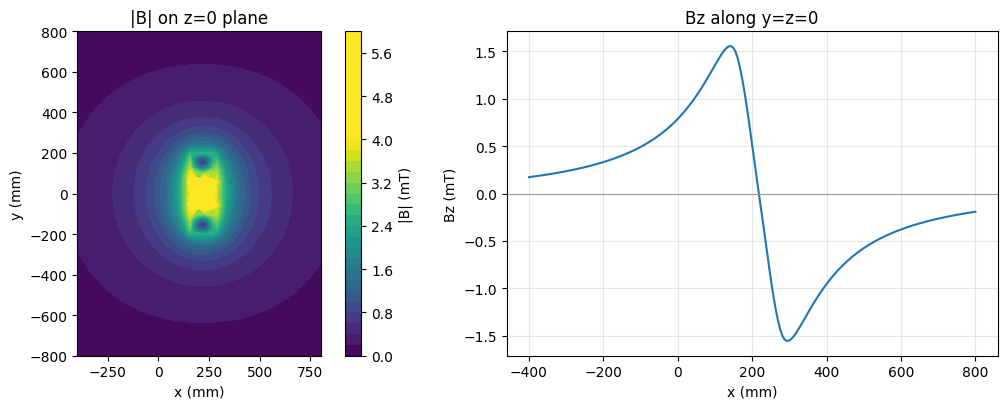


|B| range on z=0 plane: [0.09, 5.86] mT


In [2]:

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display
import radia as rad

coil, params = create_beam_steering_coil()
print("8-segment beam-steering coil:")
for k, v in params.items():
    print(f"  {k}: {v}")

# |B| on the z=0 plane above the conductor pack (the beam region).
nx, ny = 55, 70
xs = np.linspace(-0.40, 0.80, nx)
ys = np.linspace(-0.80, 0.80, ny)
Bmag = np.empty((ny, nx))
for j, y in enumerate(ys):
    for i, x in enumerate(xs):
        Bmag[j, i] = 1e3 * np.linalg.norm(rad.Fld(coil, "b", [x, y, 0.0]))  # mT

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(11, 4.2))
vmax = np.percentile(Bmag, 99)
pc = ax0.contourf(xs * 1e3, ys * 1e3, Bmag, levels=30, cmap="viridis", vmax=vmax)
fig.colorbar(pc, ax=ax0, label="|B| (mT)")
ax0.set_xlabel("x (mm)"); ax0.set_ylabel("y (mm)")
ax0.set_title("|B| on z=0 plane")
ax0.set_aspect("equal")

# Bz along the central x-axis (y=0, z=0).
xline = np.linspace(-0.40, 0.80, 200)
Bz = [1e3 * rad.Fld(coil, "b", [x, 0.0, 0.0])[2] for x in xline]
ax1.plot(xline * 1e3, Bz)
ax1.axhline(0, color="0.6", lw=0.8)
ax1.set_xlabel("x (mm)"); ax1.set_ylabel("Bz (mT)")
ax1.set_title("Bz along y=z=0")
ax1.grid(alpha=0.3)
plt.tight_layout(); display(fig); plt.close(fig)

print(f"\n|B| range on z=0 plane: [{Bmag.min():.2f}, {Bmag.max():.2f}] mT")
rad.UtiDelAll()


## Durable JSON Record

The notebook writes a compact JSON record with runtime versions, source hashes, PVSM hash, and representative field-map statistics. `field_map.py` remains the full ParaView export helper and is archived beside the notebook.

In [3]:

from pathlib import Path
import datetime as _dt
import hashlib
import importlib.metadata as _metadata
import json
import platform
import sys

NOTEBOOK_DIR = Path.cwd()
if not (NOTEBOOK_DIR / 'coil_model.py').exists():
    NOTEBOOK_DIR = Path('docs/complex_coil_geometry').resolve()


def _sha256(path):
    return hashlib.sha256(path.read_bytes()).hexdigest()


def _version(name):
    try:
        return _metadata.version(name)
    except Exception:
        return None

source_files = ['coil_model.py', 'visualize_coils.py', 'field_map.py', 'README.md']
asset_files = ['complex_coil.pvsm']
result = {
    'schema': 'radia.docs.complex_coil_geometry.results.v1',
    'generated_at_utc': _dt.datetime.now(_dt.timezone.utc).isoformat(timespec='seconds').replace('+00:00', 'Z'),
    'versions': {
        'python_version': sys.version.split()[0],
        'python_executable': sys.executable,
        'platform': platform.platform(),
        'radia_version': _version('radia'),
        'numpy_version': _version('numpy'),
    },
    'topic_dir': 'docs/complex_coil_geometry',
    'coil_parameters': {
        'current_A': float(params['current']),
        'cross_section_width_m': float(params['cross_section']['width']),
        'cross_section_height_m': float(params['cross_section']['height']),
        'num_segments': int(params['num_segments']),
        'description': params['description'],
    },
    'field_slice': {
        'nx': int(nx),
        'ny': int(ny),
        'z_m': 0.0,
        'Bmag_mT_min': float(Bmag.min()),
        'Bmag_mT_max': float(Bmag.max()),
        'Bmag_mT_mean': float(Bmag.mean()),
    },
    'source_hashes': {
        name: _sha256(NOTEBOOK_DIR / name)
        for name in source_files
        if (NOTEBOOK_DIR / name).exists()
    },
    'asset_hashes': {
        name: {'sha256': _sha256(NOTEBOOK_DIR / name), 'bytes': (NOTEBOOK_DIR / name).stat().st_size}
        for name in asset_files
        if (NOTEBOOK_DIR / name).exists()
    },
    'checks': {
        'num_segments_is_8': int(params['num_segments']) == 8,
        'field_slice_positive': float(Bmag.max()) > 0.0,
        'pvsm_present': (NOTEBOOK_DIR / 'complex_coil.pvsm').exists(),
    },
}
assert all(result['checks'].values()), result['checks']
out = NOTEBOOK_DIR / 'complex_coil_results.json'
out.write_text(json.dumps(result, ensure_ascii=False, indent=2) + '\n', encoding='utf-8')
print(f"wrote {out.relative_to(NOTEBOOK_DIR)}")
print(json.dumps(result['checks'], sort_keys=True))


wrote complex_coil_results.json
{"field_slice_positive": true, "num_segments_is_8": true, "pvsm_present": true}


## Method, implementation and scope

`CoilBuilder` composes straight and arc segments into the source used by `Fld`.
The magnetostatic reference is the Biot--Savart integral [@jackson1998classical],

$$\mathbf B(\mathbf r)=\frac{\mu_0 I}{4\pi}
\int_C\frac{d\boldsymbol\ell'\times(\mathbf r-\mathbf r')}
{|\mathbf r-\mathbf r'|^3}.$$

For a finite cross-section, replace $I\,d\boldsymbol\ell'$ by
$\mathbf J(\mathbf r')\,dV'$. The block-current integral route originates in
RADIA [@chubar1998three]; fluent path construction and artifact export are
the application layer, not an alternative field equation.

The eight-segment definition specifies dimensions in metres and excitation in
amperes; `to_radia()` constructs the actual source representation. The saved
slice and JSON field statistics demonstrate evaluation of that geometry, not
convergence of a thin-wire idealization or an inductance/loss calculation.
Near-conductor values depend on the chosen cross-section representation;
skin effect, insulation clearance and thermal limits are outside this example.
Production reproduction is requested through the Radia MCP coil/field route.


## References

Generated from the canonical bibliography: [complex_coil.bbl](complex_coil.bbl).

<h3 class='likesectionHead' id='references'><a id='x1-1000'></a>References</h3>
<!-- l. 2 --><p class='noindent'>
   </p><section class='thebibliography' role='doc-bibliography'><dl><dt>
 [1]</dt><dd><a id='Xjackson1998classical'></a>J. D. Jackson, <span class='ecti-1000'>Classical Electrodynamics</span>, 3rd ed.   Wiley, 1998.
   </dd><dt>
 [2]</dt><dd><a id='Xchubar1998three'></a>O. Chubar,               P. Elleaume,               and               J. Chavanne,
   “A three-dimensional magnetostatics computer code for insertion devices,”
   <span class='ecti-1000'>Journal of synchrotron radiation</span>, vol. 5, no. 3, pp. 481–484, 1998.
   </dd></dl></section>
